In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from vis import make_yref
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd
import seaborn as sns
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

In [49]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment1 = 'smp2'
experiment2 = 'smp0'

In [50]:
from vis import demographics
print('-----Experiment 1:')
_ = demographics(experiment1)
print('-----Experiment 2:')
_ = demographics(experiment2)

-----Experiment 1:
Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64
-----Experiment 2:
Total Participants: 10
Gender Distribution: sex
M    8
F    2
Name: count, dtype: int64
Average Age: 25.7
SD Age: 3.7727090178455764
Age Range: (np.int64(21), np.int64(32))
Handedness Distribution: handedness
right    9
left     1
Name: count, dtype: int64


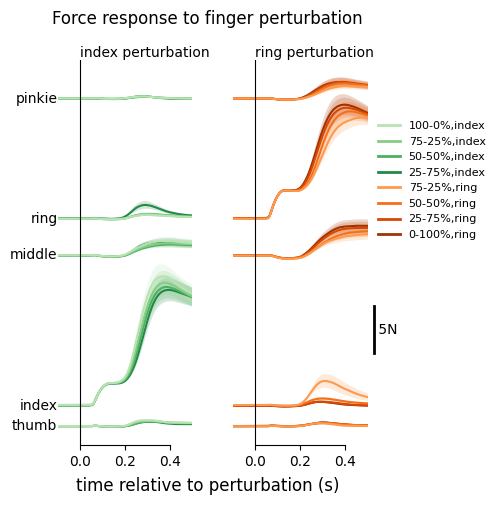

In [51]:
from vis import plot_force_aligned, add_sig_comp_bayes

npz = np.load(os.path.join(gl.baseDir, experiment1, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_force_aligned(fig, axs, force, descr)
plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 20.7316 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  7.4148 3.0000 39.0000 0.0005



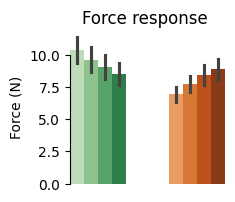

In [52]:
from vis import plot_force_binned

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(gl.baseDir, experiment1, gl.behavDir, f'{experiment1}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_force_binned(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 10)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



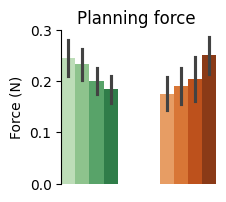

In [53]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .3)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

[]

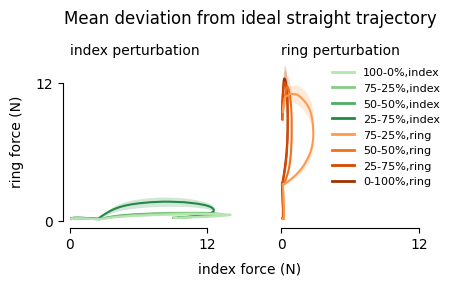

In [54]:
from vis import plot_dev_aligned

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
plot_dev_aligned(fig, axs, force, descr)

plt.plot()

rmANOVA index
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond 17.8907 1.0000 13.0000 0.0010

rmANOVA ring
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond  6.7472 1.0000 13.0000 0.0221



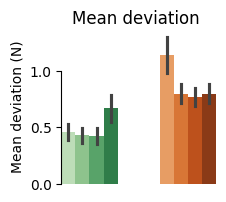

In [55]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 1)
axs[0].set_ylabel('Mean deviation (N)')
dat_stat = dat.copy()
dat_stat['correspond'] = 'high'
mask_low = ((dat_stat['cue'] == '75-25%') & (dat_stat['stimFinger'] == 'ring')) | ((dat_stat['cue'] == '25-75%') & (dat_stat['stimFinger'] == 'index'))
dat_stat.loc[mask_low, 'correspond'] = 'low'
dat_stat = dat_stat[dat_stat['GoNogo'] == 'go']

dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()

anova_index = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='index'], depvar='index1', subject='sn', within=['correspond'])
anova_ring = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['correspond'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

fig.suptitle('Mean deviation')

plt.show()

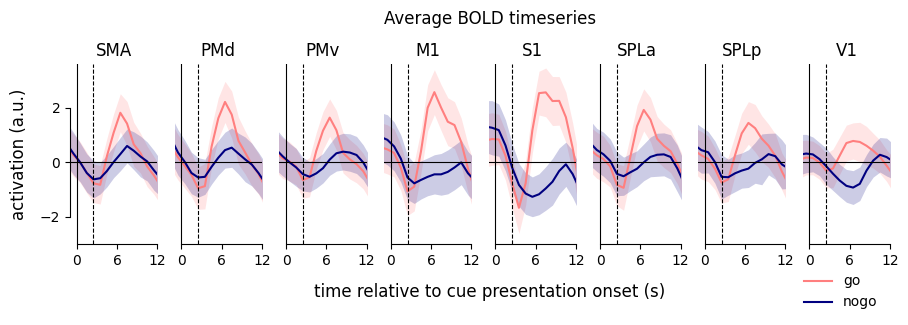

In [56]:
from vis import plot_bold

H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sns = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Ts = [os.path.join(gl.baseDir, experiment1, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in sns]
T = concat_hrf(Ts)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3))
fig, axs = plot_bold(fig, axs, T, H, rois)

plt.show()

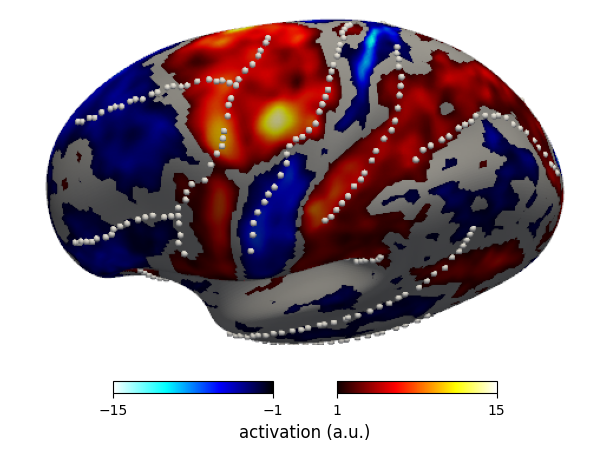

In [57]:
from vis import plot_surf

cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
H = 'L'
thresh = 1
vmin, vmax = -15, 15

cifti = nb.load(os.path.join(gl.baseDir, experiment1, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

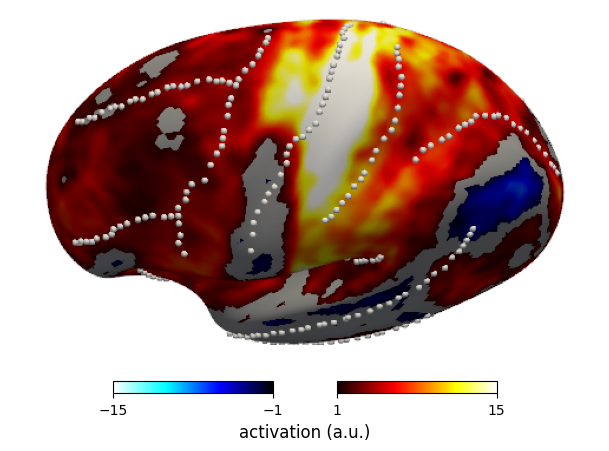

In [58]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, 'L', cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

ROI: SMA
planning vs. execution: TtestResult(statistic=np.float64(0.8024403626750395), pvalue=np.float64(0.4367228068671992), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.1092136377088915), pvalue=np.float64(0.008298280551127385), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(3.51188358507355), pvalue=np.float64(0.0038258763485076227), df=np.int64(13))
ROI: PMd
planning vs. execution: TtestResult(statistic=np.float64(0.4836842568080278), pvalue=np.float64(0.6366553764567955), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.969003198935676), pvalue=np.float64(0.0016030280845840258), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(4.378284488120725), pvalue=np.float64(0.0007469644422947125), df=np.int64(13))
ROI: PMv
planning vs. execution: TtestResult(statistic=np.float64(0.6475455695410888), pvalue=np.float64(0.5285491939388429), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(2.6257315

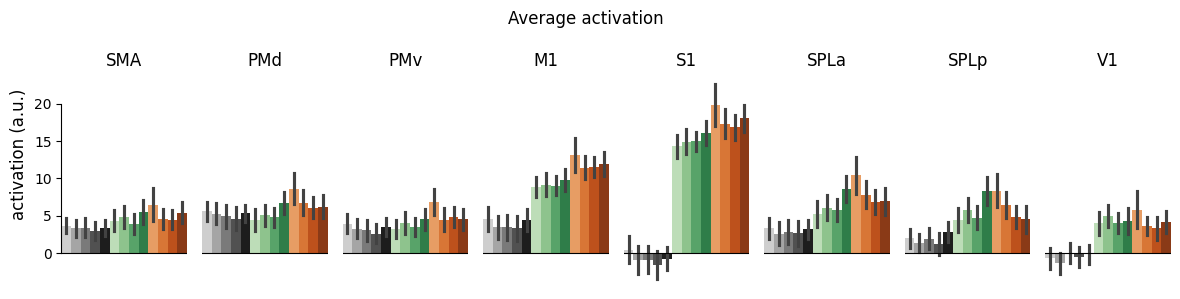

In [59]:
from vis import plot_avg_activation

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment1, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
axs[0].spines[['left', ]].set_bounds(0, 20)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    tval, pval = ttest_rel(exec, plan)
    print(f'planning vs. execution: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(plan, 0)
    print(f'planning vs. 0: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(exec, 0)
    print(f'execution vs. 0: tval={tval}, pval={pval}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()

SMA: tval=3.300955793580781, pval=0.005737159784406333
PMd: tval=5.0148966006390125, pval=0.00023664648617107995
PMv: tval=5.126117978303373, pval=0.00019463175317145707
M1: tval=4.467920932220784, pval=0.0006334441037222316
S1: tval=5.3209179421802375, pval=0.0001387693048944011
SPLa: tval=3.8209969969762083, pval=0.0021210647805612764
SPLp: tval=5.867370441922021, pval=5.524838656197924e-05
V1: tval=4.131214927010922, pval=0.0011820142293477423


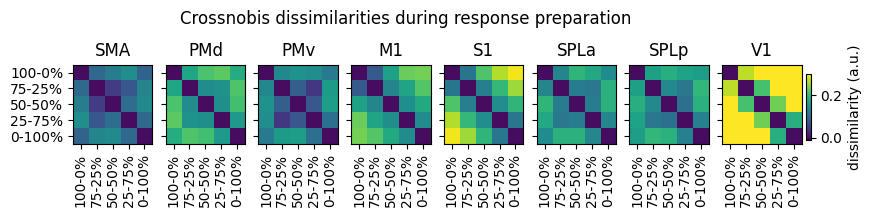

In [60]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .3

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
im = axs[-1].images[0]
fig.colorbar(im, cax=cbar_ax).set_label('dissimilarity (a.u.)', )
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

SMA: 0.7972735936691411 upper noise
PMd: 0.9363351258869357 upper noise
PMv: 0.889273657335551 upper noise
M1: 0.93593219040835 upper noise
S1: 0.9465544811496179 upper noise
SPLa: 0.8827152062993937 upper noise
SPLp: 0.9337995823382012 upper noise
V1: 0.923184097711885 upper noise
SMA, tval=2.61224859272613, pval=0.010750147289122838
PMd, tval=2.5110399366149414, pval=0.01302038060274848
PMv, tval=3.245613173611306, pval=0.00319094610780318
M1, tval=2.429336924587165, pval=0.015184328636197546
S1, tval=3.2787558832851253, pval=0.0029937669659589054
SPLa, tval=1.7779570088771024, pval=0.049397749095450895
SPLp, tval=3.3860088780062423, pval=0.0024357749550851216
V1, tval=3.5238934565219937, pval=0.0018694059316098968


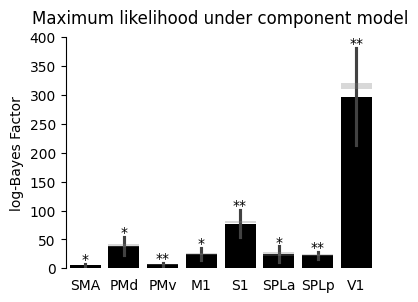

In [61]:
from vis import plot_likelihood

LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 400)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
cue, tval=1.3234838733453136, pval=0.10423940680398208
uncertainty, tval=3.289634479922843, pval=0.0029317502626668578
cue vs. uncertainty, tval=-1.2093033752880593, pval=0.24808030281898757

PMd:
cue, tval=3.2636317111634936, pval=0.003082182255764201
uncertainty, tval=4.7860666098050695, pval=0.00017780982519925945
cue vs. uncertainty, tval=-0.8699961024600151, pval=0.4000818590128169

PMv:
cue, tval=2.448540074620318, pval=0.014646615032568415
uncertainty, tval=2.552723390338354, pval=0.01203413413680442
cue vs. uncertainty, tval=-1.280386044526166, pval=0.22278381994242105

M1:
cue, tval=3.0428070361382735, pval=0.004714792278142219
uncertainty, tval=2.3823924022956686, pval=0.016579661442354822
cue vs. uncertainty, tval=2.9051054563935303, pval=0.012286908493713514

S1:
cue, tval=7.6520656190485425, pval=1.813034081578061e-06
uncertainty, tval=2.5552820858384075, pval=0.011976007674595855
cue vs. uncertainty, tval=3.7142435815603876, pval=0.002598530904714729

SPLa:
cue, tva

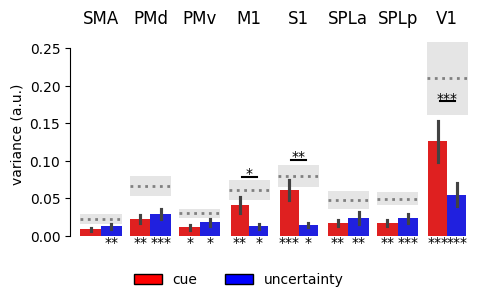

In [62]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'M.plan.p'), 'component')
n_param_c = Mc.n_param
components = ['cue', 'uncertainty']
palette = ['red', 'blue']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

Likelihood of cue model
tval=2.4601259124512476, pval=0.014331091593496511
0.93 noise ceiling
force: tval=3.2106057951069467, pval=0.006826772009600081


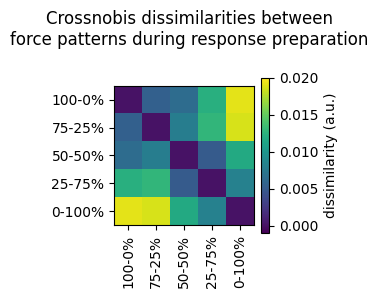

In [63]:
fig, ax = plt.subplots(figsize=(2, 3))

vmin, vmax = -.001, .02

T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_cv.force.plan.p'))

bf_cue = T_cv.likelihood['cue'] - T_cv.likelihood['null']
bf_noise = T_cv.likelihood['ceil'] - T_cv.likelihood['null']

tval, pval = ttest_1samp(bf_cue, 0, alternative='greater')
print(f'Likelihood of cue model\ntval={tval}, pval={pval}')
print(f'{bf_cue.mean() / bf_noise.mean():.02f} noise ceiling')

G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.force.plan.npy'))
fig, ax = plot_dissimilarities(fig, ax, None, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarities between\nforce patterns during response preparation')

plt.show()


M1


IndexError: list index out of range

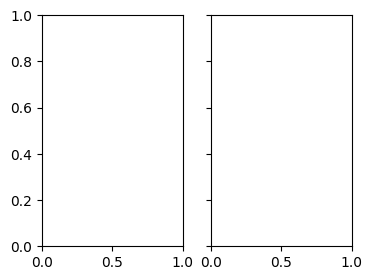

In [70]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']
diff = np.zeros(len(sns))
pcm_path = os.path.join(gl.baseDir, experiment1, gl.pcmDir)
for s, sn in enumerate(sns):
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment1, gl.behavDir, f'subj{sn}', f'{experiment1}_{sn}.dat'), sep='\t')
    diff[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    f = open(os.path.join(pcm_path, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    var_expl = np.exp(param_c)
    x = diff
    y = var_expl[0]
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[2], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('variance explained by cue (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('finger pre-activation (N)', fontsize=10)

fig.suptitle('Finger pre-activation\nvs. variance explained by cue')

fig.tight_layout()

plt.show()

SMA: tval=4.2793011460081125, pval=0.0008970443809763396
PMd: tval=5.428670627363977, pval=0.00011534455093643085
PMv: tval=4.649301486748749, pval=0.0004550959697409745
M1: tval=4.236357242321517, pval=0.0009715277600851284
S1: tval=3.8314661049277894, pval=0.002079344661485911
SPLa: tval=5.04594339140568, pval=0.00022404332770238733
SPLp: tval=5.207762324891715, pval=0.00016879626846480516
V1: tval=6.083097308399899, pval=3.885068905292104e-05


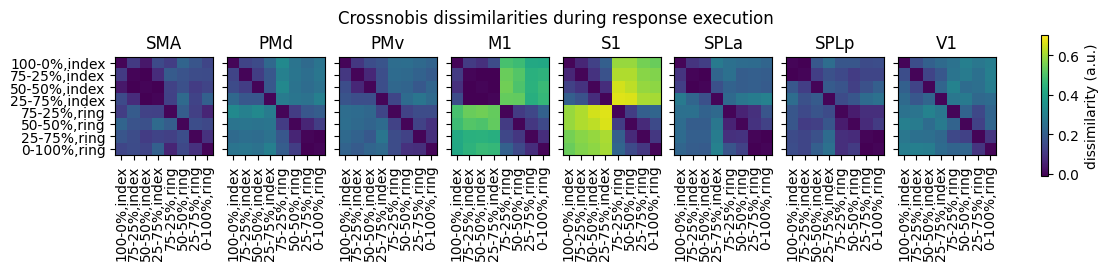

In [65]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

SMA: 0.0856498253064907 upper noise
PMd: 0.13537936153971 upper noise
PMv: 0.1284797610133694 upper noise
M1: 0.6003429377067401 upper noise
S1: 0.7005063897760869 upper noise
SPLa: 0.13616841824814327 upper noise
SPLp: 0.14472224485936144 upper noise
V1: 0.06087328825479713 upper noise
SMA, tval=3.712891935711547, pval=0.0013026163217349195
PMd, tval=9.021261945049746, pval=2.93135738103984e-07
PMv, tval=4.427983068199469, pval=0.000340821224536223
M1, tval=3.7810388894807443, pval=0.0011441578126719233
S1, tval=4.080379522558004, pval=0.0006500450301419965
SPLa, tval=5.2692496549310155, pval=7.585996595846112e-05
SPLp, tval=3.206480246071782, pval=0.00344060340338985
V1, tval=2.6612266548572454, pval=0.009794391207764569


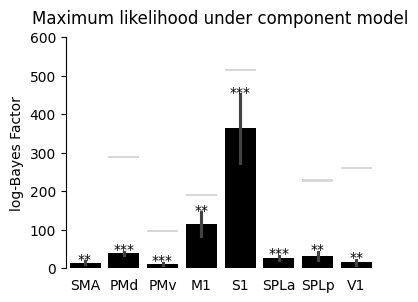

In [66]:
LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_cv.exec.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_gr.exec.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 600)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
finger, tval=2.618053261177949, pval=0.010632302980762403
cue, tval=0.7354513928597635, pval=0.23756248739386465
surprise, tval=3.7525637582355524, pval=0.001207831755896685
finger vs. cue, tval=2.2681057621140743, pval=0.04101194542057276
finger vs. surprise, tval=-4.39244804628166, pval=0.0007277145621942545
cue vs. surprise, tval=-7.641946792516585, pval=3.6782095775731013e-06

PMd:
finger, tval=5.6838142379809, pval=3.746510921984692e-05
cue, tval=1.2509118196221711, pval=0.1165059592091929
surprise, tval=6.4583523112707875, pval=1.0691520707413233e-05
finger vs. cue, tval=4.366703459279516, pval=0.0007630950229700426
finger vs. surprise, tval=-1.2434770138503197, pval=0.2356499596017059
cue vs. surprise, tval=-8.286862722930374, pval=1.517347778609558e-06

PMv:
finger, tval=3.447975144481811, pval=0.002162448739585374
cue, tval=-79.5444720775201, pval=1.0
surprise, tval=3.9849550645659297, pval=0.00077777164217192
finger vs. cue, tval=1.889999484991586, pval=0.08126080855602

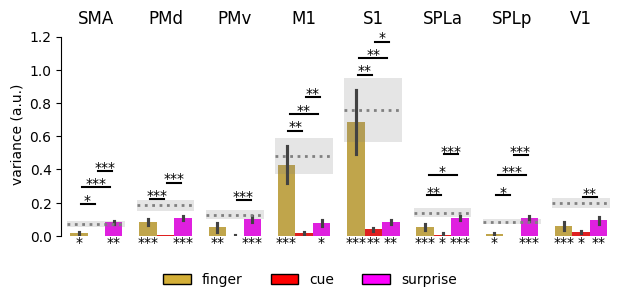

In [67]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
palette = ['#D4AF37', 'red', 'magenta']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(7, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

SMA, tval=-1031990.768034978, pval=2.5088285239531515e-72
PMd, tval=-2320860.281456833, pval=6.665298240485974e-77
PMv, tval=-900582.8323777692, pval=1.4738351414568334e-71
M1, tval=-19.01344793628338, pval=7.184076328426889e-11
S1, tval=-15.132974351429045, pval=1.2380415240762103e-09
SPLa, tval=-68.51232856455643, pval=5.069628584159612e-18
SPLp, tval=-1491570.6383306202, pval=2.088751639793484e-74
V1, tval=-46.105396958829004, pval=8.558927550830269e-16


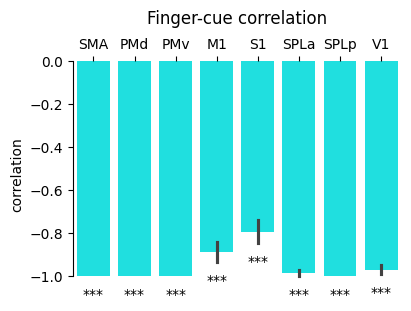

In [68]:
from vis import plot_interaction, add_sig_to_bars

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, 'M.exec.p'), 'feature')
# Mc, idxc = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, 'M.exec.p'), 'component')
n_param_f = Mf.n_param
# n_param_c = Mc.n_param
interaction = {'roi': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment1, gl.pcmDir)
for roi in rois:
    f = open(os.path.join(pcm_path, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    theta = param[idxf][:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    interaction['roi'].extend([roi] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction)
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='roi')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-1])
ax.set_title('Finger-cue correlation', pad=10)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

SMA
group estimate:-0.9999999731958947 central 90% CI for r: [-1.000, -1.000]
PMd
group estimate:-0.4481911753857935 central 90% CI for r: [-1.000, -0.251]
PMv
group estimate:-0.999999939936347 central 90% CI for r: [-1.000, -1.000]
M1
group estimate:0.5761691475952214 central 90% CI for r: [0.419, 0.677]
S1
group estimate:0.5983963035548011 central 90% CI for r: [0.456, 0.707]
SPLa
group estimate:-0.9445546841011776 central 90% CI for r: [-1.000, -0.691]
SPLp
group estimate:-0.9999999998398916 central 90% CI for r: [-1.000, -1.000]
V1
group estimate:0.37522480456462703 central 90% CI for r: [0.229, 0.488]


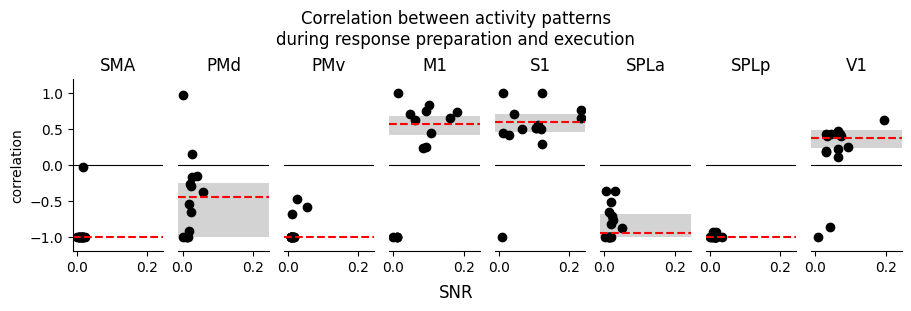

In [69]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)
rois_tmp = ['PMd','M1', 'S1','SPLa']

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    print(roi)
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'r_bootstrap.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between activity patterns\nduring response preparation and execution')

plt.show()
